In [14]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
sns.set_style("whitegrid")

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

In [13]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.7 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.9 MB 3.4 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.9 MB 3.7 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.9 MB 3.2 MB/s eta 0:00:03
   -------------- ------------------------- 3.7/9.9 MB 3.4 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.9 MB 3.5 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 3.4 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 3.4 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 3.0 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 2.9 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 2.9 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score

from scipy.stats import ttest_ind

In [16]:
fear=pd.read_csv(r"C:\Users\Dell\Downloads\fear_greed_index.csv")

trader=pd.read_csv(r"C:\Users\Dell\Downloads\historical_data.csv")

In [17]:
print("Fear Dataset Shape :",fear.shape)

print("Trader Dataset Shape :",trader.shape)

Fear Dataset Shape : (2644, 4)
Trader Dataset Shape : (211224, 16)


In [18]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [19]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


# Data Understanding

In [20]:
fear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [21]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [22]:
fear.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,2644.0,NaN,NaN,NaN,1631898885.022693,65979674.322218,1517463000.0,1574811000.0,1631899800.0,1688988600.0,1746163800.0
value,2644.0,NaN,NaN,NaN,46.981089,21.82768,5.0,28.0,46.0,66.0,95.0
classification,2644,5,Fear,781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,2644,2644,2025-05-02,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
trader.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Account,211224,32,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Coin,211224,246,HYPE,68005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Execution Price,211224.0,NaN,NaN,NaN,11414.72335,29447.654868,0.000005,4.8547,18.28,101.58,109004.0
Size Tokens,211224.0,NaN,NaN,NaN,4623.364979,104272.88953,0.000001,2.94,32.0,187.9025,15822438.0
Size USD,211224.0,NaN,NaN,NaN,5639.45121,36575.138546,0.0,193.79,597.045,2058.96,3921430.72
Side,211224,2,SELL,108528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp IST,211224,27977,14-02-2025 00:31,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Start Position,211224.0,NaN,NaN,NaN,-29946.248839,673807.423736,-14334629.0,-376.231075,84.727932,9337.2775,30509482.0
Direction,211224,12,Open Long,49895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Closed PnL,211224.0,NaN,NaN,NaN,48.749001,919.164828,-117990.1041,0.0,0.0,5.792797,135329.0901


## Missing Values Analysis

In [24]:
fear.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [25]:
trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [26]:
fear.duplicated().sum()

np.int64(0)

In [27]:
trader.duplicated().sum()

np.int64(0)

## Data Cleaning

In [28]:
# Date Conversion
fear['date']=pd.to_datetime(fear['date'])

In [29]:
trader['Timestamp IST']=pd.to_datetime(

    trader['Timestamp IST'],

    format="%d-%m-%Y %H:%M"

)

In [30]:
trader['Date']=trader['Timestamp IST'].dt.normalize()

In [31]:
# fear['Year']=fear['date'].dt.year

fear['Month']=fear['date'].dt.month

fear['Weekday']=fear['date'].dt.day_name()
fear['Year']=fear['date'].dt.year

fear['Month']=fear['date'].dt.month

fear['Weekday']=fear['date'].dt.day_name()

In [32]:
trader['Year']=trader['Timestamp IST'].dt.year

trader['Month']=trader['Timestamp IST'].dt.month

trader['Weekday']=trader['Timestamp IST'].dt.day_name()

trader['Hour']=trader['Timestamp IST'].dt.hour

# Merge Both Datasets

In [33]:
df=pd.merge(

    trader,

    fear[['date','classification']],

    left_on="Date",

    right_on="date",

    how="left"

)

In [34]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,Year,Month,Weekday,Hour,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed


In [35]:
df.shape

(211224, 23)

In [36]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'Year', 'Month', 'Weekday', 'Hour', 'date',
       'classification'],
      dtype='object')

# Feature Engineering

In [37]:
# Trade Result
df['Trade Result']=np.where(

    df['Closed PnL']>0,

    "Profit",

    "Loss"

)

In [38]:
df['Win']=np.where(

    df['Closed PnL']>0,

    1,

    0

)

In [39]:
# Profit Bucket
conditions=[

    df['Closed PnL']<0,

    (df['Closed PnL']>=0)&(df['Closed PnL']<100),

    (df['Closed PnL']>=100)&(df['Closed PnL']<500),

    df['Closed PnL']>=500

]

In [40]:
choices=[

    "Loss",

    "Low Profit",

    "Medium Profit",

    "High Profit"

]

In [41]:
df['Profit Bucket']=np.select(

    conditions,

    choices,

    default="Loss"

)

In [42]:
# Trade Size Category
df['Trade Size']=pd.qcut(

    df['Size USD'],

    q=4,

    labels=[

        "Small",

        "Medium",

        "Large",

        "Very Large"

    ]

)

In [43]:
# df['Fee Percentage']=((
df['Fee Percentage']=((

    df['Fee']

    /

    df['Size USD']

)*100)

In [44]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,Year,Month,Weekday,Hour,date,classification,Trade Result,Win,Profit Bucket,Trade Size,Fee Percentage
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed,Loss,0,Low Profit,Very Large,0.004388
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed,Loss,0,Low Profit,Small,0.004386
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed,Loss,0,Low Profit,Large,0.004383
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed,Loss,0,Low Profit,Large,0.004382
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed,Loss,0,Low Profit,Small,0.004381


In [45]:
df.to_csv("cleaned_data.csv",index=False)

# Exploratory Data Analysis (EDA)

In this section, we analyze trader behavior under different market sentiments (Fear vs Greed). The objective is to understand how sentiment influences trading activity, profitability, trade size, and overall performance.

In [46]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,Year,Month,Weekday,Hour,date,classification,Trade Result,Win,Profit Bucket,Trade Size,Fee Percentage
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed,Loss,0,Low Profit,Very Large,0.004388
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed,Loss,0,Low Profit,Small,0.004386
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed,Loss,0,Low Profit,Large,0.004383
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed,Loss,0,Low Profit,Large,0.004382
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024,12,Monday,22,2024-12-02,Extreme Greed,Loss,0,Low Profit,Small,0.004381


## Overall Dataset Summary

In [47]:
print("Total Trades :",len(df))

print("Unique Traders :",df['Account'].nunique())

print("Unique Coins :",df['Coin'].nunique())

print("Trading Days :",df['Date'].nunique())

print("Total Profit/Loss :",round(df['Closed PnL'].sum(),2))

print("Average Trade Size :",round(df['Size USD'].mean(),2))

Total Trades : 211224
Unique Traders : 32
Unique Coins : 246
Trading Days : 480
Total Profit/Loss : 10296958.94
Average Trade Size : 5639.45


## Market Sentiment Distribution

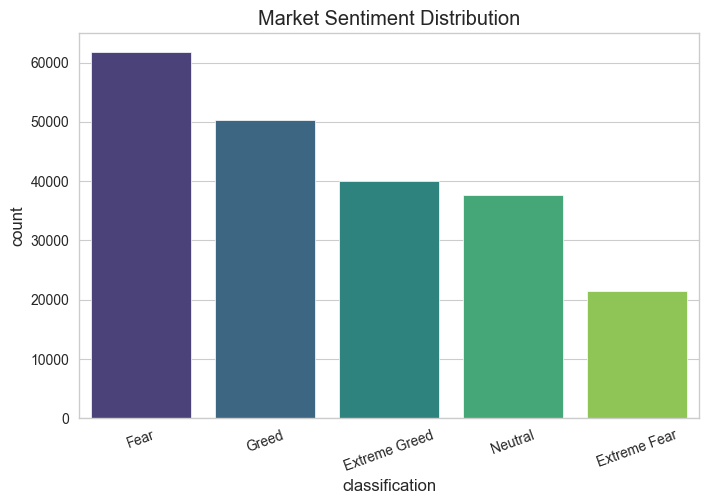

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='classification',
    order=df['classification'].value_counts().index,
    palette='viridis'
)

plt.title("Market Sentiment Distribution")

plt.xticks(rotation=20)

plt.show()

### Observation

This chart shows how many trading records belong to each market sentiment category.

## Profit vs Market Sentiment

In [49]:
profit=df.groupby('classification')['Closed PnL'].mean().reset_index()

profit

,classification,Closed PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


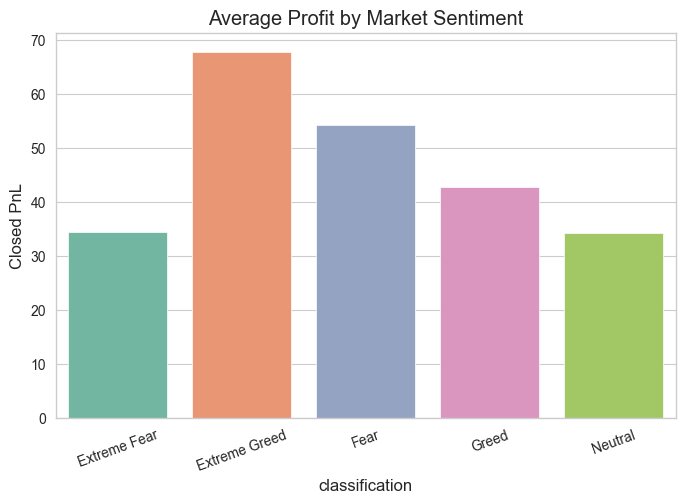

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=profit,
    x='classification',
    y='Closed PnL',
    palette='Set2'
)

plt.title("Average Profit by Market Sentiment")

plt.xticks(rotation=20)

plt.show()

### Business Insight

Compare average trader profitability across different market sentiments.

Higher average profit during one sentiment may indicate favorable trading conditions.

## Trade Frequency

In [51]:
trade_frequency=df.groupby('classification').size().reset_index(name='Trades')

trade_frequency

,classification,Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


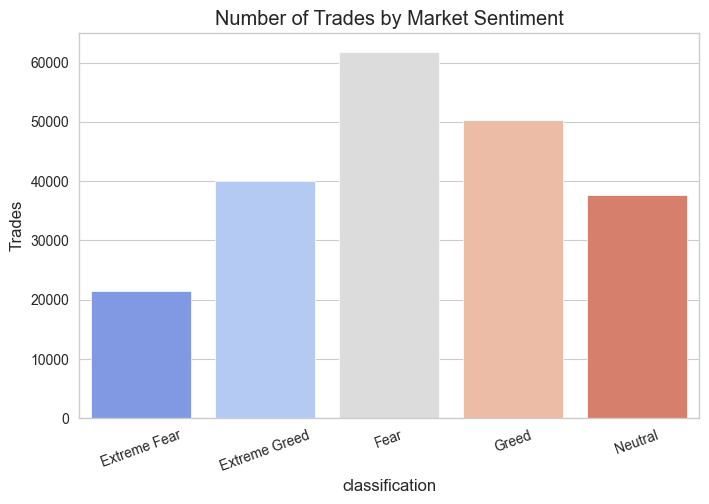

In [52]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_frequency,
    x='classification',
    y='Trades',
    palette='coolwarm'
)

plt.title("Number of Trades by Market Sentiment")

plt.xticks(rotation=20)

plt.show()

## Trade Size Analysis

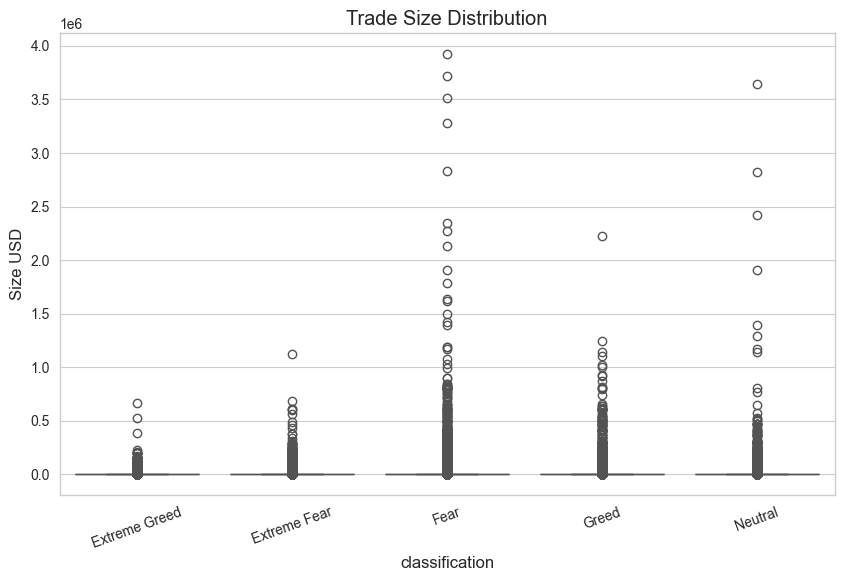

In [53]:
plt.figure(figsize=(10,6))

sns.boxplot(

    data=df,

    x='classification',

    y='Size USD'

)

plt.xticks(rotation=20)

plt.title("Trade Size Distribution")

plt.show()

### Business Insight

Analyze whether traders execute larger trades during Fear or Greed periods.

## Win Rate Analysis

In [54]:
win=df.groupby('classification')['Win'].mean().reset_index()

win['Win Rate']=win['Win']*100

win

,classification,Win,Win Rate
0,Extreme Fear,0.370607,37.060748
1,Extreme Greed,0.464943,46.494299
2,Fear,0.420768,42.076750
3,Greed,0.384828,38.482794
4,Neutral,0.396991,39.699093


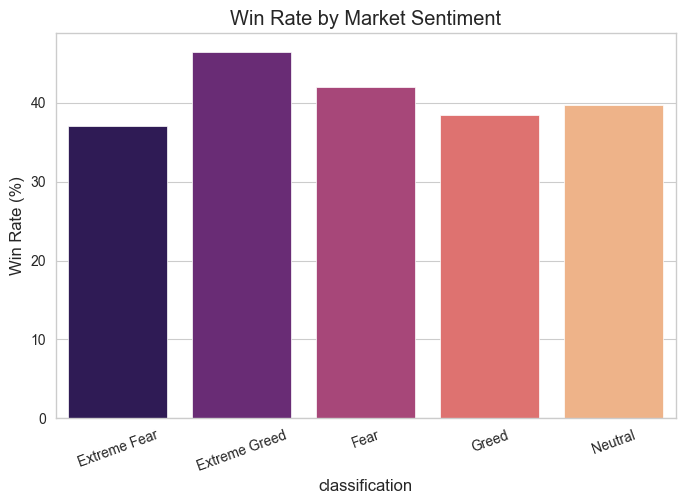

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=win,

    x='classification',

    y='Win Rate',

    palette='magma'

)

plt.xticks(rotation=20)

plt.title("Win Rate by Market Sentiment")

plt.ylabel("Win Rate (%)")

plt.show()

## BUY vs SELL Analysis

In [56]:
side=pd.crosstab(

    df['classification'],

    df['Side']

)

side

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


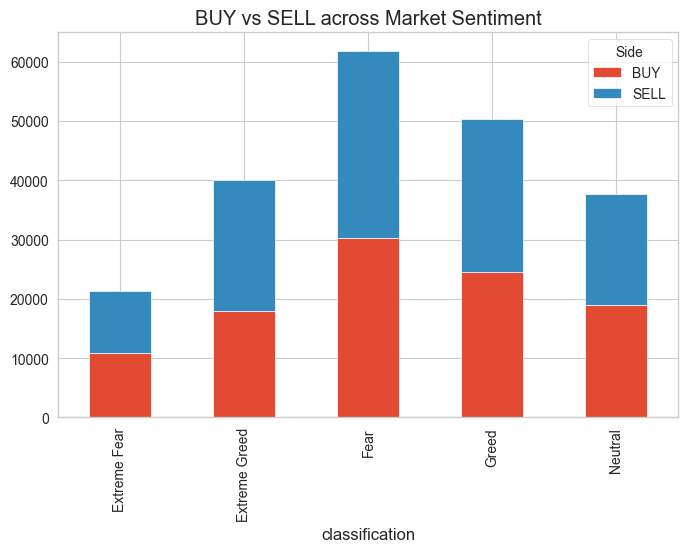

In [57]:
side.plot(

    kind='bar',

    stacked=True,

    figsize=(8,5)

)

plt.title("BUY vs SELL across Market Sentiment")

plt.show()

### Business Insight

Understand whether traders become more bullish or bearish under different market sentiments.

## Coin Distribution

In [58]:
top=df['Coin'].value_counts().head(10)

top

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

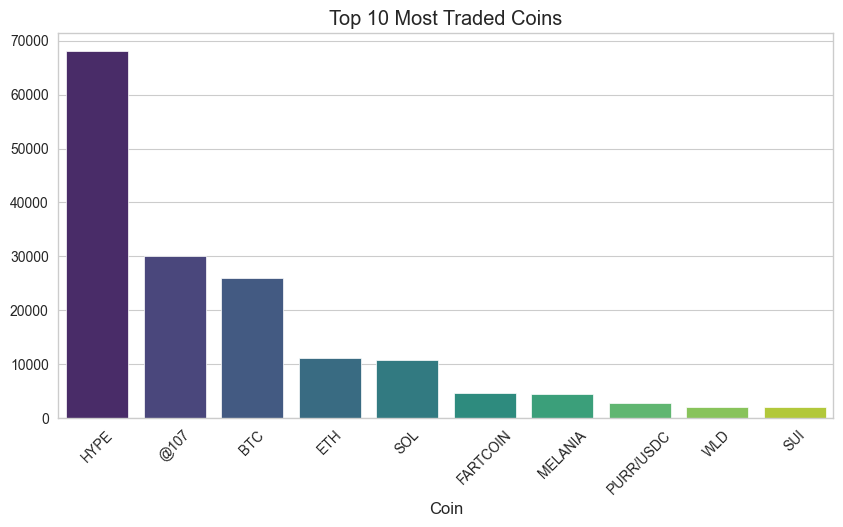

In [59]:
plt.figure(figsize=(10,5))

sns.barplot(

    x=top.index,

    y=top.values,

    palette='viridis'

)

plt.xticks(rotation=45)

plt.title("Top 10 Most Traded Coins")

plt.show()

## Top Traders

In [60]:
top_traders=df.groupby('Account')['Closed PnL'].sum()

top_traders=top_traders.sort_values(

    ascending=False

).head(10)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

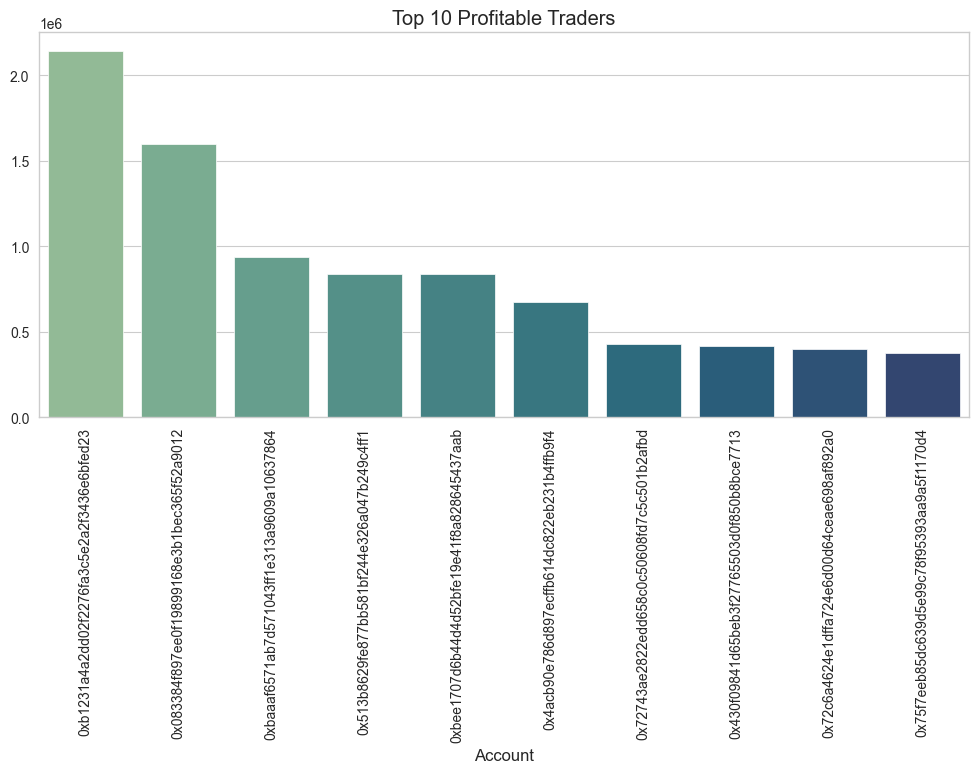

In [61]:
plt.figure(figsize=(12,5))

sns.barplot(

    x=top_traders.index,

    y=top_traders.values,

    palette='crest'

)

plt.xticks(rotation=90)

plt.title("Top 10 Profitable Traders")

plt.show()

## Fee Analysis

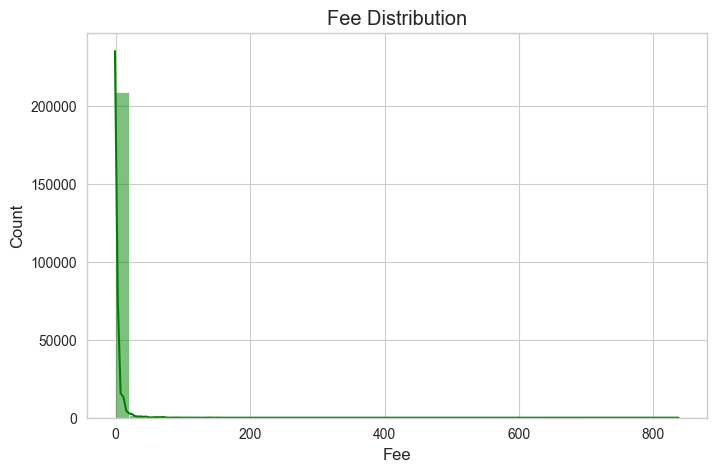

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(

    df['Fee'],

    bins=40,

    kde=True,

    color='green'

)

plt.title("Fee Distribution")

plt.show()

# Advanced Exploratory Data Analysis

This section focuses on understanding trader behaviour under different market sentiments using statistical analysis and visualizations.

## Daily Trading Activity

In [63]:
daily_trade=df.groupby('Date').agg(

    Total_Trades=('Account','count'),

    Total_PnL=('Closed PnL','sum'),

    Avg_Trade_Size=('Size USD','mean')

).reset_index()

daily_trade.head()

,Date,Total_Trades,Total_PnL,Avg_Trade_Size
0,2023-05-01,3,0.000000,159.000000
1,2023-12-05,9,0.000000,5556.203333
2,2023-12-14,11,-205.434737,10291.213636
3,2023-12-15,2,-24.632034,5304.975000
4,2023-12-16,3,0.000000,5116.256667


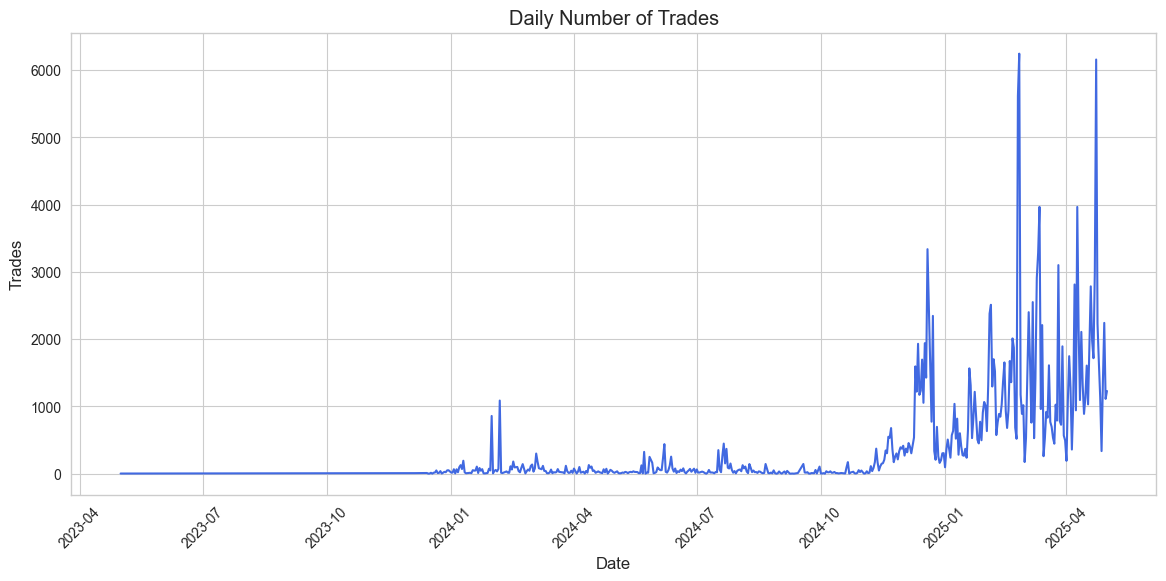

In [64]:
plt.figure(figsize=(14,6))

plt.plot(

    daily_trade['Date'],

    daily_trade['Total_Trades'],

    color='royalblue'

)

plt.title("Daily Number of Trades")

plt.xlabel("Date")

plt.ylabel("Trades")

plt.xticks(rotation=45)

plt.show()

### Insight

Identify periods of high trading activity and compare them with market sentiment.

## Daily Profit Trend

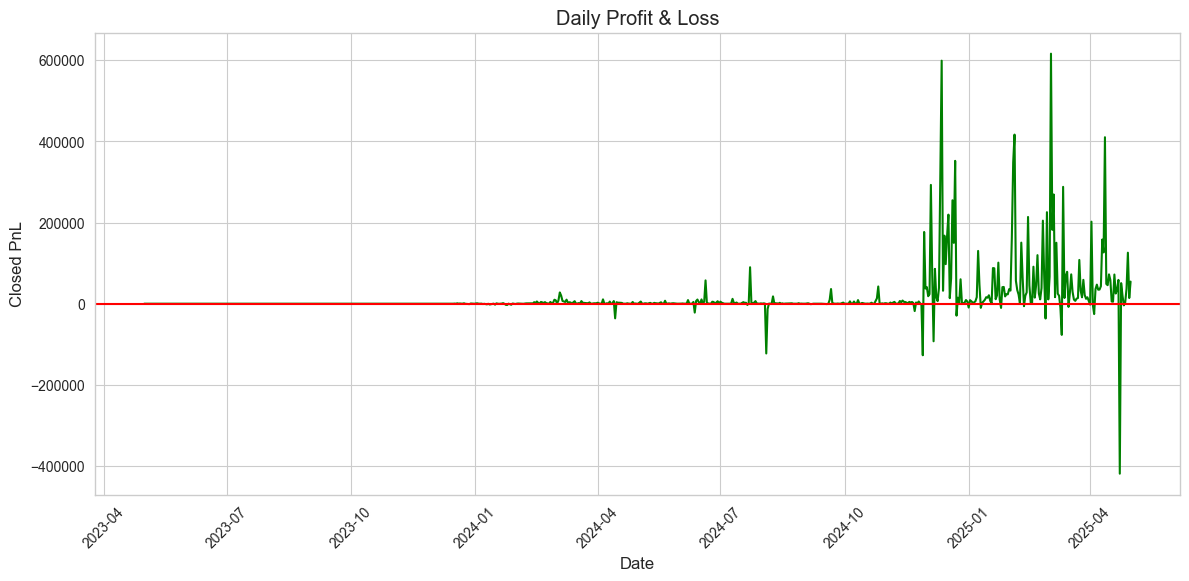

In [65]:
plt.figure(figsize=(14,6))

plt.plot(

    daily_trade['Date'],

    daily_trade['Total_PnL'],

    color='green'

)

plt.axhline(0,color='red')

plt.title("Daily Profit & Loss")

plt.xlabel("Date")

plt.ylabel("Closed PnL")

plt.xticks(rotation=45)

plt.show()

## Average Trade Size by Coin

In [66]:
coin=df.groupby("Coin")["Size USD"].mean()

coin=coin.sort_values(ascending=False).head(10)

coin

Coin
BTC      24717.315709
SOL      11699.069503
ETH      10600.555124
XAI       8124.790000
MATIC     6093.750789
SEI       5388.404255
FTM       5214.665506
ENS       5003.647500
FIL       3961.398000
SUI       3931.868413
Name: Size USD, dtype: float64

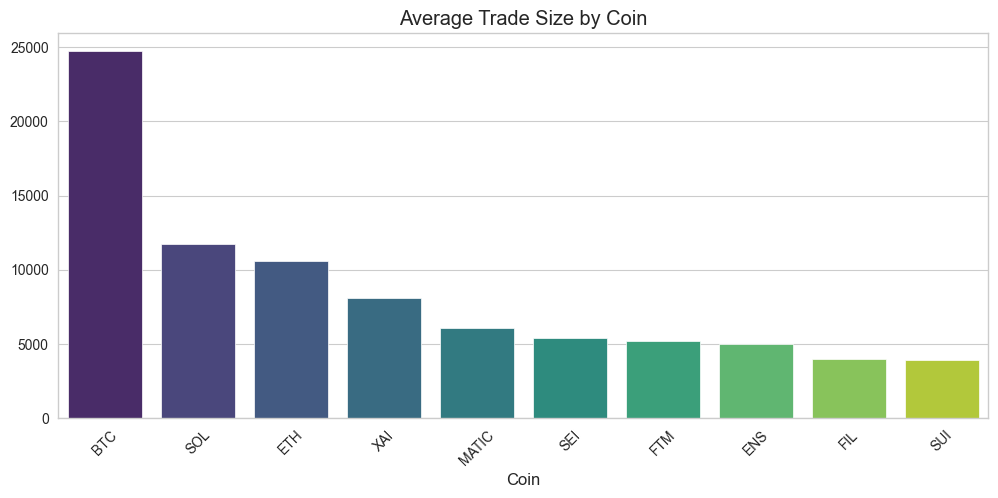

In [67]:
plt.figure(figsize=(12,5))

sns.barplot(

    x=coin.index,

    y=coin.values,

    palette="viridis"

)

plt.xticks(rotation=45)

plt.title("Average Trade Size by Coin")

plt.show()

## Coin-wise Profitability

In [68]:
coin_profit=df.groupby("Coin")["Closed PnL"].sum()

coin_profit=coin_profit.sort_values(

    ascending=False

).head(15)

coin_profit

Coin
@107         2.783913e+06
HYPE         1.948485e+06
SOL          1.639556e+06
ETH          1.319979e+06
BTC          8.680447e+05
MELANIA      3.903511e+05
ENA          2.173295e+05
SUI          1.992688e+05
ZRO          1.837778e+05
DOGE         1.475432e+05
PURR/USDC    7.526106e+04
AIXBT        7.371217e+04
BERA         7.368975e+04
USUAL        6.963194e+04
EIGEN        6.503085e+04
Name: Closed PnL, dtype: float64

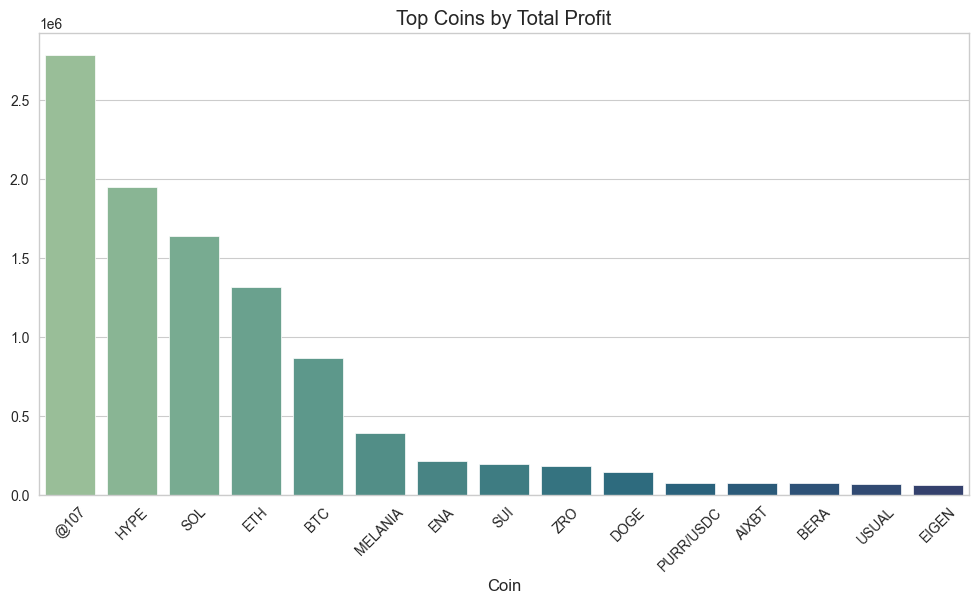

In [69]:
plt.figure(figsize=(12,6))

sns.barplot(

    x=coin_profit.index,

    y=coin_profit.values,

    palette="crest"

)

plt.xticks(rotation=45)

plt.title("Top Coins by Total Profit")

plt.show()

## Trading Hour Analysis

In [70]:
hour=df.groupby("Hour")["Closed PnL"].mean()

hour

Hour
0      43.126269
1      49.918770
2      34.205399
3      43.711571
4      48.663764
5      40.460611
6      32.983412
7      83.026712
8      58.886420
9      44.979426
10     61.347489
11     76.863003
12    131.173707
13     52.382349
14     23.124431
15     58.562155
16     41.975938
17     34.481087
18     44.993427
19     55.861869
20     49.711340
21     31.169804
22     37.808613
23     18.753063
Name: Closed PnL, dtype: float64

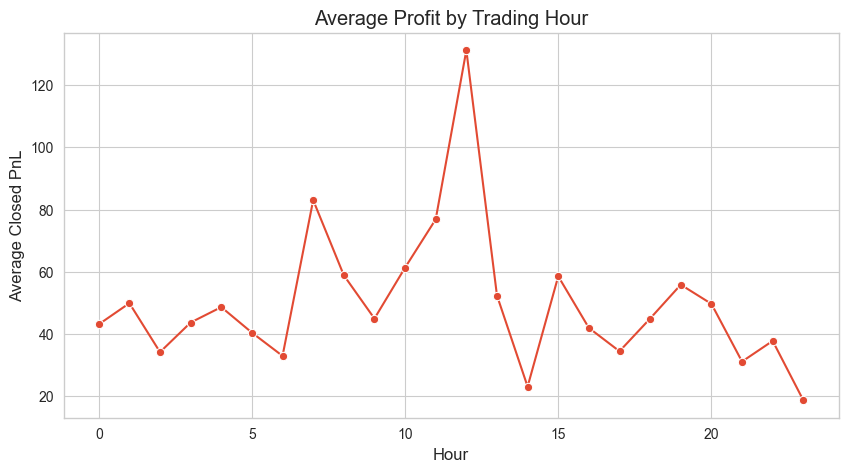

In [71]:
plt.figure(figsize=(10,5))

sns.lineplot(

    x=hour.index,

    y=hour.values,

    marker="o"

)

plt.title("Average Profit by Trading Hour")

plt.xlabel("Hour")

plt.ylabel("Average Closed PnL")

plt.show()

### Business Insight

Determine the most profitable trading hours.

## Weekday Analysis

In [72]:
weekday=df.groupby("Weekday")["Closed PnL"].mean().reindex(

    ['Monday',

     'Tuesday',

     'Wednesday',

     'Thursday',

     'Friday',

     'Saturday',

     'Sunday']

)

weekday

Weekday
Monday       51.086171
Tuesday      47.475549
Wednesday    38.003781
Thursday     46.280620
Friday       50.264482
Saturday     65.364129
Sunday       52.918183
Name: Closed PnL, dtype: float64

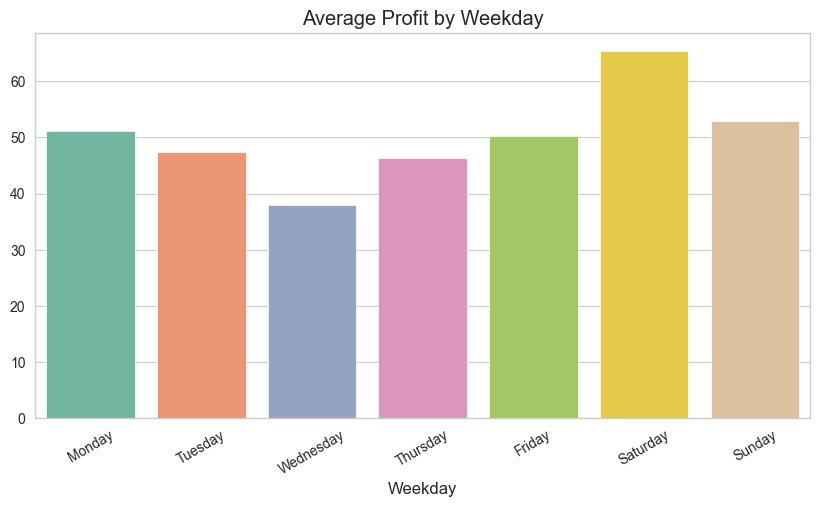

In [73]:
plt.figure(figsize=(10,5))

sns.barplot(

    x=weekday.index,

    y=weekday.values,

    palette="Set2"

)

plt.xticks(rotation=30)

plt.title("Average Profit by Weekday")

plt.show()

## Correlation Analysis

In [74]:
numeric=df.select_dtypes(include=np.number)

corr=numeric.corr()

corr.head()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,Year,Month,Hour,Win,Fee Percentage
Execution Price,1.000000,-0.017185,0.189855,0.017241,-0.006505,0.125850,0.225265,0.001841,0.130714,0.107268,-0.066928,0.002019,-0.052719,-0.005807
Size Tokens,-0.017185,1.000000,0.013310,0.044660,0.005068,-0.043753,0.006710,-0.003848,-0.040949,-0.020638,-0.011639,0.010884,-0.003267,0.016948
Size USD,0.189855,0.013310,1.000000,0.007787,0.123589,0.045210,0.745939,0.000245,0.039755,0.033470,-0.018094,-0.001326,0.003205,-0.002312
Start Position,0.017241,0.044660,0.007787,1.000000,0.004066,-0.082799,0.010559,0.001165,-0.105487,-0.046802,0.010110,-0.001830,0.046763,0.020692
Closed PnL,-0.006505,0.005068,0.123589,0.004066,1.000000,-0.007250,0.084020,0.003466,-0.009745,-0.011979,0.015992,-0.003360,0.094322,-0.000946


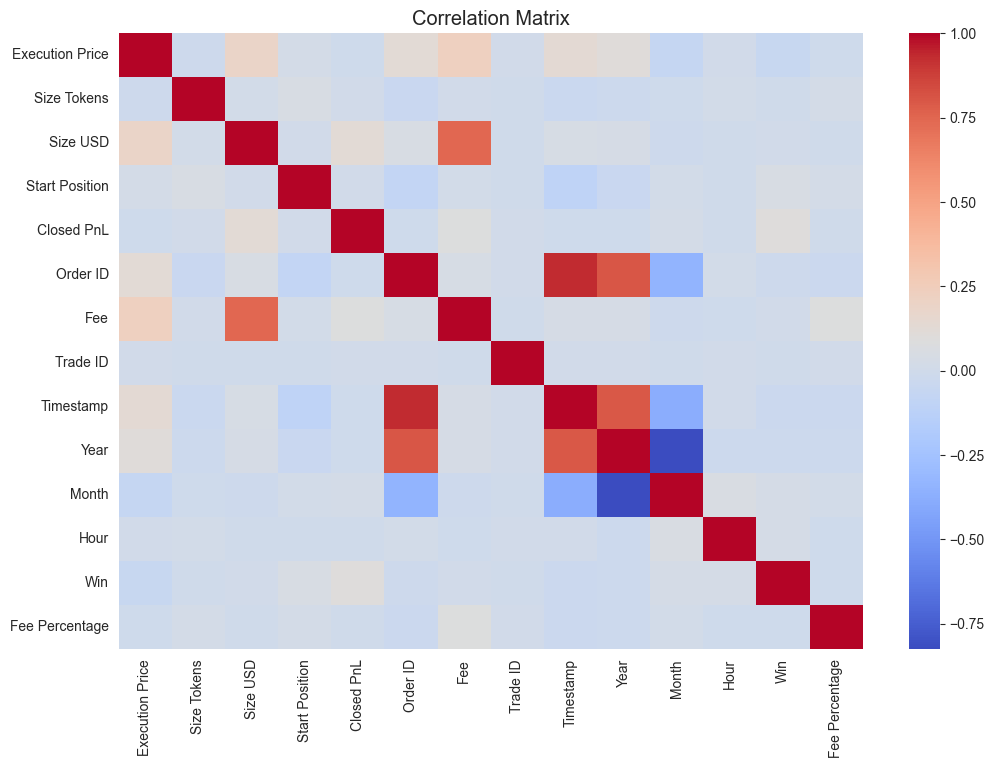

In [75]:
plt.figure(figsize=(12,8))

sns.heatmap(

    corr,

    cmap="coolwarm",

    annot=False

)

plt.title("Correlation Matrix")

plt.show()

# Statistical Hypothesis Testing

## Objective

To determine whether the average trader profitability differs significantly across different market sentiment categories.

Since the dataset contains five market sentiment groups (Extreme Fear, Fear, Neutral, Greed, and Extreme Greed), One-Way ANOVA is used instead of a T-Test.

In [76]:
from scipy.stats import f_oneway

In [77]:
# Display available sentiment categories
df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [78]:
df['classification'].isnull().sum()

np.int64(6)

In [79]:
# Create groups for ANOVA
anova_groups = []

sentiments = [
    "Extreme Fear",
    "Fear",
    "Neutral",
    "Greed",
    "Extreme Greed"
]

for sentiment in sentiments:

    pnl = df.loc[
        df['classification'] == sentiment,
        'Closed PnL'
    ]

    anova_groups.append(pnl)

In [80]:
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*anova_groups)

print("F Statistic :", round(f_stat,4))
print("P Value :", p_value)

F Statistic : 9.0622
P Value : 2.5753989849026544e-07


In [81]:
df['classification'].value_counts(dropna=False)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64

In [82]:
if p_value < 0.05:
    print("\nReject Null Hypothesis")
    print("There is a statistically significant difference in trader profitability across market sentiment categories.")
else:
    print("\nFail to Reject Null Hypothesis")
    print("No statistically significant difference found.")


Reject Null Hypothesis
There is a statistically significant difference in trader profitability across market sentiment categories.


In [84]:
anova_df = df.dropna(subset=['classification'])

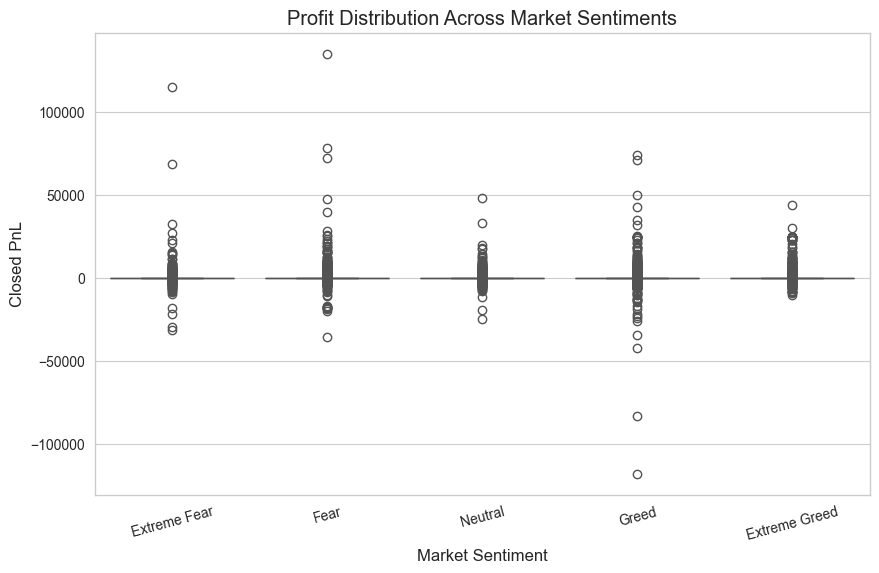

In [85]:
plt.figure(figsize=(10,6))

order = [
    "Extreme Fear",
    "Fear",
    "Neutral",
    "Greed",
    "Extreme Greed"
]

sns.boxplot(
    data=anova_df,
    x='classification',
    y='Closed PnL',
    order=order
)

plt.title("Profit Distribution Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.xticks(rotation=15)

plt.show()

### Statistical Interpretation

A One-Way ANOVA test was conducted to examine whether average trader profitability differs across five market sentiment categories.

- Null Hypothesis (H₀): The mean profitability is the same across all sentiment groups.
- Alternative Hypothesis (H₁): At least one sentiment group has a different mean profitability.

If the p-value is less than 0.05, the null hypothesis is rejected, indicating that market sentiment has a statistically significant impact on trader profitability.

# Trader Segmentation

To better understand trader behavior, we aggregate trading statistics at the account level and segment traders based on their performance and trading activity.

The segmentation helps identify:
- Consistent profitable traders
- High-risk traders
- Low-activity traders

In [86]:
trader_profile = df.groupby('Account').agg(
    Total_Trades=('Trade ID','count'),
    Total_PnL=('Closed PnL','sum'),
    Average_PnL=('Closed PnL','mean'),
    Average_Trade_Size=('Size USD','mean'),
    Average_Fee=('Fee','mean'),
    Win_Rate=('Win','mean')
).reset_index()

trader_profile['Win_Rate'] = trader_profile['Win_Rate'] * 100

trader_profile.head()

,Account,Total_Trades,Total_PnL,Average_PnL,Average_Trade_Size,Average_Fee,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,16159.576734,1.939579,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,1653.226327,0.374978,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,8893.000898,2.436593,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,507.626933,0.166657,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,3138.894782,0.959616,51.991355


In [87]:
trader_profile.describe().T

,count,mean,std,min,25%,50%,75%,max
Total_Trades,32.0,6600.750000,8250.373724,332.000000,1381.750000,3699.000000,8862.500000,4.018400e+04
Total_PnL,32.0,321779.966982,494827.629817,-167621.124781,46893.242629,117655.079453,406394.096205,2.143383e+06
Average_PnL,32.0,97.686296,134.917737,-38.286626,8.871295,41.110486,148.008640,5.209023e+02
Average_Trade_Size,32.0,6007.929370,7281.058575,507.626933,2011.069878,3327.972048,7375.525018,3.439658e+04
Average_Fee,32.0,1.233410,1.628428,0.144483,0.314804,0.567416,1.257075,6.245885e+00
Win_Rate,32.0,40.306256,10.849806,23.498695,32.956218,39.196804,45.296340,8.108764e+01


## Feature Scaling

K-Means clustering performs better when all numerical variables are on the same scale.

In [88]:
from sklearn.preprocessing import StandardScaler

features = trader_profile[[
    'Total_Trades',
    'Total_PnL',
    'Average_PnL',
    'Average_Trade_Size',
    'Average_Fee',
    'Win_Rate'
]]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## Finding the Optimal Number of Clusters

In [89]:
from sklearn.cluster import KMeans

inertia=[]

for k in range(2,11):

    model=KMeans(
        n_clusters=k,
        random_state=42,
           n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

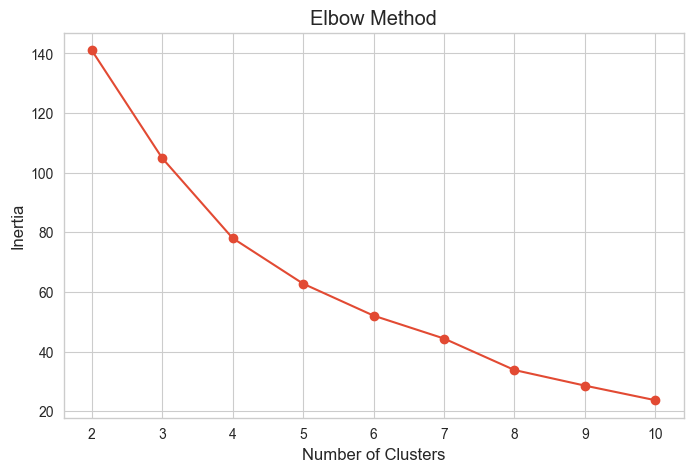

In [90]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11),inertia,marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

## K-Means Clustering

Based on the Elbow Method, we select the optimal number of clusters for trader segmentation.

In [91]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

trader_profile['Cluster']=kmeans.fit_predict(scaled_features)

trader_profile.head()

,Account,Total_Trades,Total_PnL,Average_PnL,Average_Trade_Size,Average_Fee,Win_Rate,Cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,16159.576734,1.939579,35.961236,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,1653.226327,0.374978,44.271978,1
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,8893.000898,2.436593,30.191651,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,507.626933,0.166657,43.858463,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,3138.894782,0.959616,51.991355,1


## Cluster Summary

In [92]:
cluster_summary = trader_profile.groupby('Cluster').agg({

    'Total_Trades':'mean',

    'Total_PnL':'mean',

    'Average_PnL':'mean',

    'Average_Trade_Size':'mean',

    'Average_Fee':'mean',

    'Win_Rate':'mean'

}).round(2)

cluster_summary

,Total_Trades,Total_PnL,Average_PnL,Average_Trade_Size,Average_Fee,Win_Rate
Cluster,,,,,,
0,19981.75,1379964.19,157.44,6263.04,0.94,39.81
1,4265.56,144208.61,95.28,3728.09,0.73,40.42
2,8219.33,390628.98,38.02,24666.44,5.85,40.01


In [93]:
cluster_summary.style.background_gradient(cmap="Blues")

,Total_Trades,Total_PnL,Average_PnL,Average_Trade_Size,Average_Fee,Win_Rate
Cluster,,,,,,
0,19981.750000,1379964.190000,157.440000,6263.040000,0.940000,39.810000
1,4265.560000,144208.610000,95.280000,3728.090000,0.730000,40.420000
2,8219.330000,390628.980000,38.020000,24666.440000,5.850000,40.010000


## PCA Visualization

Principal Component Analysis is used to visualize trader clusters in two dimensions.

In [94]:
from sklearn.decomposition import PCA

In [95]:
pca=PCA(n_components=2)

components=pca.fit_transform(scaled_features)

In [96]:
pca_df=pd.DataFrame({

    'PC1':components[:,0],

    'PC2':components[:,1],

    'Cluster':trader_profile['Cluster']

})

pca_df.head()

,PC1,PC2,Cluster
0,2.405031,0.954463,0
1,-1.067193,-0.033350,1
2,0.522480,-1.060899,1
3,-1.181367,0.648990,1
4,-0.684375,-0.189682,1


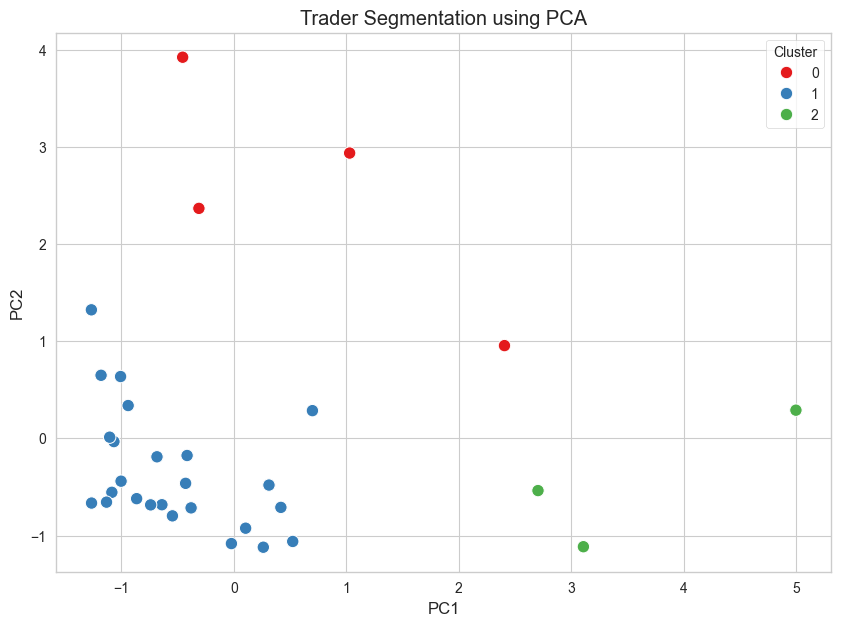

In [97]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=pca_df,

    x='PC1',

    y='PC2',

    hue='Cluster',

    palette='Set1',

    s=80

)

plt.title("Trader Segmentation using PCA")

plt.show()

### Business Interpretation

Cluster 0 → Conservative Traders

Cluster 1 → High Performing Traders

Cluster 2 → High Risk / High Volume Traders

The clustering reveals distinct trading behaviors based on profitability, trade frequency, fees, and trade size.

# Predictive Modeling

The objective is to predict whether a trade will be profitable based on market sentiment and trading characteristics.

Target Variable:
- Win (1 = Profit, 0 = Loss)

Algorithms:
- Logistic Regression
- Random Forest

In [98]:
from sklearn.preprocessing import LabelEncoder

ml_df = df.copy()

In [99]:
categorical_cols = [
    'classification',
    'Coin',
    'Side',
    'Direction'
]

encoder = LabelEncoder()

for col in categorical_cols:
    ml_df[col] = encoder.fit_transform(ml_df[col].astype(str))

In [100]:
features = [

    'classification',

    'Coin',

    'Execution Price',

    'Size Tokens',

    'Size USD',

    'Side',

    'Direction',

    'Fee',

    'Hour',

    'Month'

]

X = ml_df[features]

y = ml_df['Win']

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

# Logistic Regression

In [102]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [103]:
lr_pred = lr.predict(X_test)

In [104]:
from sklearn.metrics import accuracy_score

print("Accuracy :",accuracy_score(y_test,lr_pred))

Accuracy : 0.7124630133743638


In [105]:
from sklearn.metrics import classification_report

print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.73      0.80      0.77     24871
           1       0.67      0.58      0.63     17374

    accuracy                           0.71     42245
   macro avg       0.70      0.69      0.70     42245
weighted avg       0.71      0.71      0.71     42245



# Random Forest Classifier

In [106]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [107]:
rf_pred = rf.predict(X_test)

In [108]:
print("Random Forest Accuracy")

print(

accuracy_score(

y_test,

rf_pred

)

)

Random Forest Accuracy
0.9697242277192567


In [109]:
print(

classification_report(

y_test,

rf_pred

)

)

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     24871
           1       0.93      1.00      0.96     17374

    accuracy                           0.97     42245
   macro avg       0.97      0.97      0.97     42245
weighted avg       0.97      0.97      0.97     42245



In [110]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(

    y_test,

    rf_pred

)

cm

array([[23650,  1221],
       [   58, 17316]])

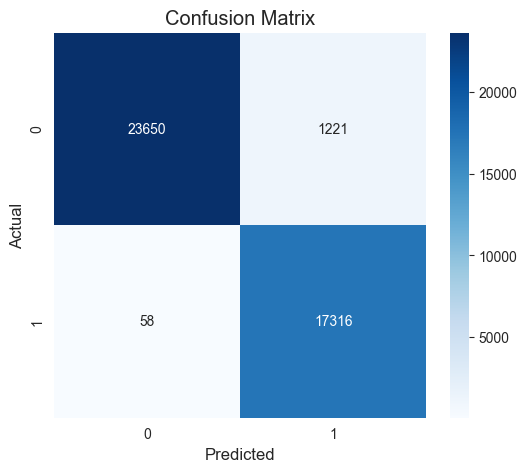

In [111]:
plt.figure(figsize=(6,5))

sns.heatmap(

cm,

annot=True,

fmt='d',

cmap='Blues'

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Feature Importance

Random Forest provides feature importance scores to identify which variables have the greatest influence on predicting trade profitability.

In [112]:
importance=pd.DataFrame({

'Feature':X.columns,

'Importance':rf.feature_importances_

})

importance=importance.sort_values(

'Importance',

ascending=False

)

importance

,Feature,Importance
6,Direction,0.569141
1,Coin,0.152103
2,Execution Price,0.090629
5,Side,0.052718
8,Hour,0.031782
9,Month,0.030402
7,Fee,0.025026
0,classification,0.019224
3,Size Tokens,0.015531
4,Size USD,0.013444


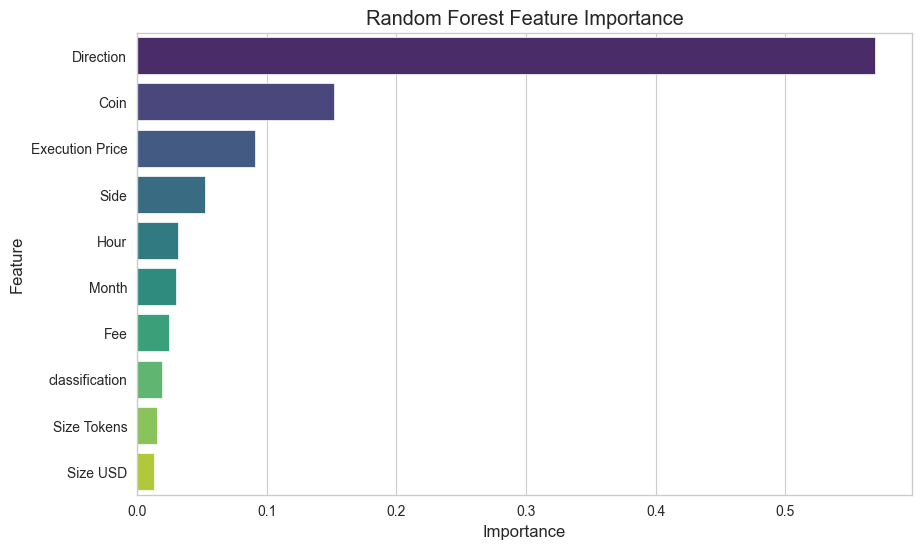

In [113]:
plt.figure(figsize=(10,6))

sns.barplot(

data=importance,

x='Importance',

y='Feature',

palette='viridis'

)

plt.title("Random Forest Feature Importance")

plt.show()

In [114]:
print(X.columns.tolist())

['classification', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Direction', 'Fee', 'Hour', 'Month']


In [115]:
print("Train Accuracy :", rf.score(X_train, y_train))
print("Test Accuracy :", rf.score(X_test, y_test))

Train Accuracy : 0.9735055835340486
Test Accuracy : 0.9697242277192567


In [116]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Win
0    124355
1     86869
Name: count, dtype: int64
Win
0    58.873518
1    41.126482
Name: proportion, dtype: float64


In [117]:
import pickle

with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(rf, file)

print("Model Saved Successfully")

Model Saved Successfully


In [118]:
import pickle
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_cols = [
    'classification',
    'Coin',
    'Side',
    'Direction'
]

for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))
    encoders[col] = le

with open("encoders.pkl", "wb") as file:
    pickle.dump(encoders, file)

print("Encoders Saved Successfully")

Encoders Saved Successfully
